# mechanism_viewer examples

## Use comparison plots to suggest missing data mechanisms

This notebook contains examples of how to use functions from `viewer_comparison.py` to compare an observed column against the missingness of another column.

> Note: These plots are exploratory. Therefore, they should be used together with additional testing before concluding a missing data mechanism of a column.

### 1. Generate synthetic dataset with missing values

The dataset below has one complete column and multiple columns with different missing data mechanisms and different data types. 

In [1]:
from mechanism_viewer import generate_dataset_with_missing_data, ColType

data = generate_dataset_with_missing_data(200, [ColType.CONTINUOUS, ColType.DISCRETE, ColType.DISC_CATEGORICAL,
                                                ColType.BINARY], 1, ["MAR", "MCAR", "MNAR"], [0.2, 0.2, 0.2])

display(data.head(10))

,Col1,Col2,Col3,Col4
0,0.496714,11,4,0
1,-0.138264,7,5,1
2,0.647689,3,<NA>,0
3,1.523030,<NA>,0,0
4,-0.234153,3,6,1
5,-0.234137,4,<NA>,0
6,1.579213,<NA>,9,0
7,0.767435,<NA>,9,1
8,-0.469474,4,1,0
9,0.542560,3,1,0


### 2. Scatter comparison with `scatter_missingness_comparison()`

The function `scatter_missingness_comparison()` plots a `scatterplot` using the data points of `(column_name, is_not_missing(missing_col))`, to show whether missingness patterns of `missing_col` appear associated with values in an observed column, such as `column_name`.

Moreover, the function returns `(figure, axis)` and can display directly with `display_plot=True`.

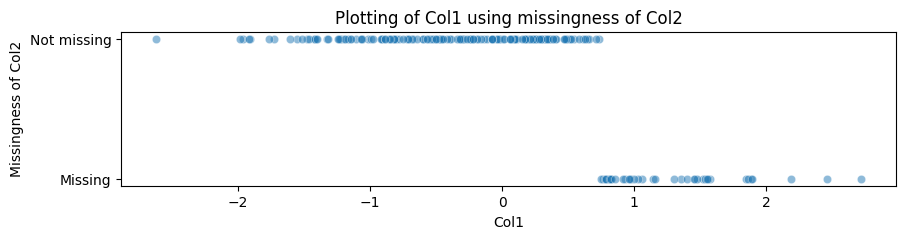

In [2]:
from mechanism_viewer import scatter_missingness_comparison

fig_comp, ax_comp = scatter_missingness_comparison(data, column_name="Col1", missing_col="Col2", display_plot=True)

### 3. Line scatter comparison with `scatter_missingness_comparison_line()`

This variant of `scatter_missingness_comparison()` places all points on one horizontal line, and colors the points by the missingness class (Missing/Not missing). This way, the function `scatter_missingness_comparison_line()` can make the delimiation of each class easier to inspect, and thus, make the missing data mechanism of the missing column easier to perceive.

The function also returns a `(figure, axis)` tuple, and has the option of setting `display_plot=True` to display the plot in the notebook.

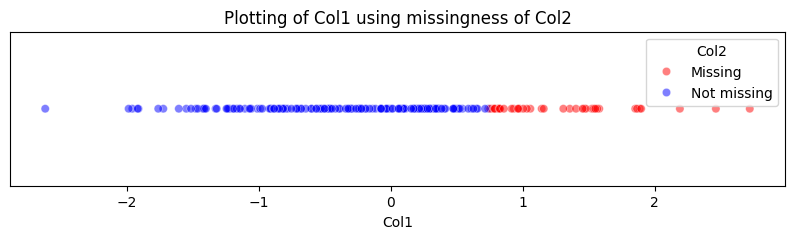

In [3]:
from mechanism_viewer import scatter_missingness_comparison_line

fig_comp_line, ax_comp_line = scatter_missingness_comparison_line(data, column_name="Col1", missing_col="Col2", display_plot=True)

### 4. Boxplot comparison with `boxplot_comparison()`

This function compares the distribution of `column_name` across three different groups. The first group plots the rows where `missing_col` is not missing. The second group has the rows where `missing_col` is missing. At last, the final group plots all rows of `column_name`.

The function returns a `(figure, axis)` tuple, so that the user can adapt the plot to their wish. In addition, by setting `display_plot=True`, the function will also display the plot inside the notebook.

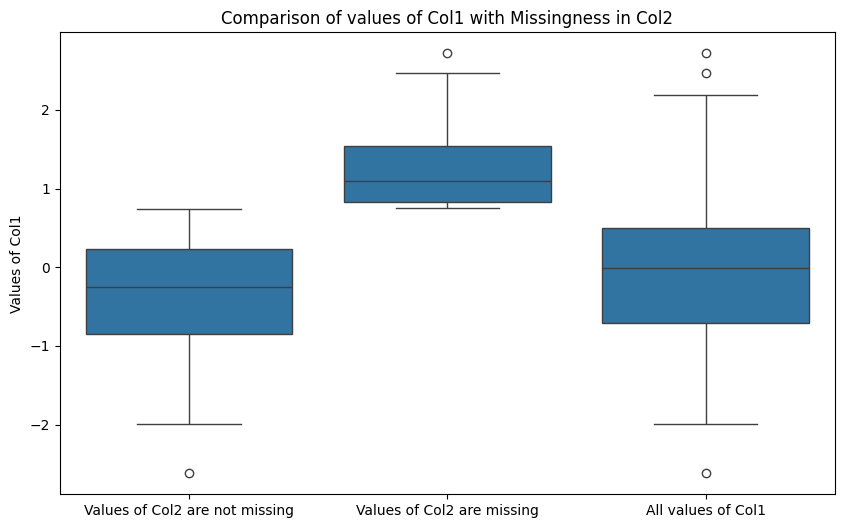

In [4]:
from mechanism_viewer import boxplot_comparison

fig_boxplot, ax_boxplot = boxplot_comparison( data, column_name="Col1", missing_col="Col2", display_plot=True)

The next code showcases an example of customization of the previous plot.

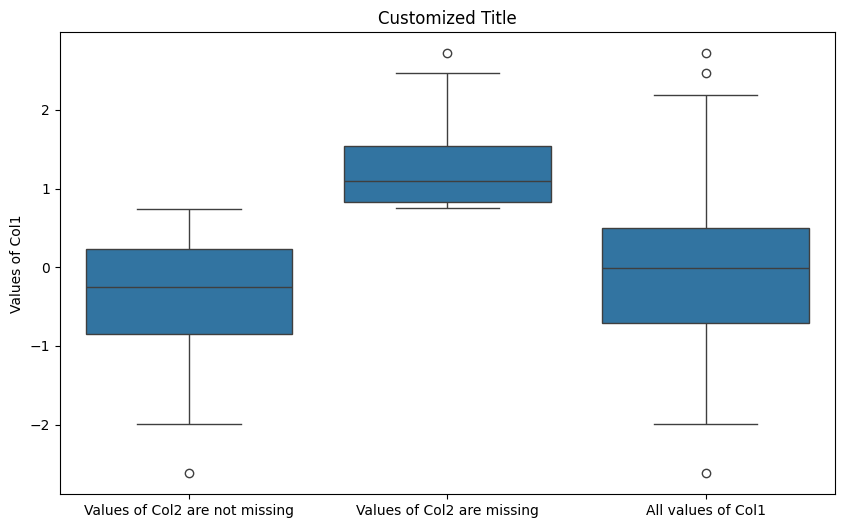

In [5]:
ax_boxplot.set_title("Customized Title")
fig_boxplot